In [1]:
import os, sys
from pathlib import Path
ROOT = Path().resolve().parent  # notebooks/ -> project root
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src' / '2_gold'))

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, WeibullAFTFitter, KaplanMeierFitter
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
ROOT      = Path().resolve()
DATA_PATH = ROOT / "data" / "processed"

In [3]:
from cap3_survival_features import (
    gerar_features_survival,
    preparar_survival,
    JANELAS, DURACAO, FONTES_PARTIDO,
    ARQUIVOS_RECEITAS, ler_tab_receitas, tratar_df_receita,
    COVS_MODELO,
)

In [4]:
rrd = pd.read_parquet(DATA_PATH / "rrd_df_novo.parquet")
rrd["nr_candidato"] = rrd["nr_candidato"].astype(str)

# alias para consistência com células abaixo
rrd["dias_primeira_receita"] = rrd["dias_desde_inicio"]

ELEITO_CATS = ["ELEITO", "ELEITO POR MEDIA", "MEDIA", "ELEITO POR QP"]
rrd["eleito"] = rrd["ds_sit_tot_turno"].isin(ELEITO_CATS).astype(int)

rrd_df_merge = gerar_features_survival(rrd)

print("candidato_competitivo:", rrd_df_merge["candidato_competitivo"].value_counts().to_dict())

candidato_competitivo: {False: 20690, True: 2793}


In [5]:
survival_dfs = {ano: preparar_survival(rrd_df_merge, ano) for ano in [2014, 2018, 2022]}
df_surv_14, df_surv_18, df_surv_22 = (
    survival_dfs[2014], survival_dfs[2018], survival_dfs[2022]
)
for ano, df in survival_dfs.items():
    ev   = int(df["event"].sum())
    cens = int((df["event"] == 0).sum())
    pct  = ev / len(df) * 100
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"{ano}{label} — N={len(df):,} | eventos={ev:,} ({pct:.0f}%) | censurados={cens:,}")

2014 (pré-FEFC / FP) — N=6,177 | eventos=2,298 (37%) | censurados=3,879
2018 — N=7,626 | eventos=5,336 (70%) | censurados=2,290
2022 — N=9,672 | eventos=8,566 (89%) | censurados=1,106


## Modelo de Duração: Tempo até o Primeiro Repasse

A variável dependente é o número de dias desde o início da campanha até o primeiro repasse de recursos partidários ao candidato.

- **Evento:** primeiro repasse de recursos ao candidato
- **Origem do tempo:** início oficial da campanha — 2014: 06/07 (FP, pré-FEFC) | 2018/2022: 16/08 (FEFC+FP)
- **Censura à direita:** candidatos que não receberam nenhum repasse são censurados ao final da janela (2014: 91 dias | 2018: 52 dias | 2022: 47 dias)
- **2014 como baseline pré-FEFC:** o mecanismo em 2014 é o Fundo Partidário (descentralizado); a comparação com 2018/2022 ilustra o efeito da introdução do FEFC

A censura não é aleatória — representa a decisão do partido de não transferir recursos — e será discutida como tal na tese.

Todos os preditores são observáveis **antes** da eleição: histórico eleitoral acumulado e desempenho intralista na eleição anterior. O resultado eleitoral não entra como preditor para evitar a circularidade diagnosticada por Bolognesi et al. (2020) e Guarnieri & Silva (2025).

In [6]:
# Kaplan-Meier — competitivo vs. não-competitivo
# Layout 2×3:
#   Linha 1 → 2014 Total (todos os recursos) | 2014 FP | 2014 PJ→Partido
#   Linha 2 → 2018                            | 2022   | (vazio)

cores_km  = {"Candidato competitivo": "black",     "Candidato não-competitivo": "lightgrey"}
dashes_km = {"Candidato competitivo": "solid",      "Candidato não-competitivo": "dot"}
grupos_km = ["Candidato competitivo", "Candidato não-competitivo"]

cs_lookup = rrd_df_merge[
    ["ano_eleicao", "sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]
].drop_duplicates()

# Dados transacionais 2014 para sub-painéis FP e PJ_ROTEADO
_df14_raw = tratar_df_receita(ler_tab_receitas(ARQUIVOS_RECEITAS[2014]), 2014)
_df14_raw["nr_candidato"] = _df14_raw["nr_candidato"].astype(str)
_df14_raw["dias_campanha"] = (_df14_raw["dt_receita"] - JANELAS[2014][0]).dt.days

_cands_2014 = (
    cs_lookup[cs_lookup["ano_eleicao"] == 2014]
    [["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]]
    .drop_duplicates()
)


def _km_2014(fonte_tipos=None):
    src = _df14_raw if fonte_tipos is None else _df14_raw[_df14_raw["fonte_tipo"].isin(fonte_tipos)]
    first = (
        src.groupby(["sg_uf", "sg_partido", "nr_candidato"])["dias_campanha"]
        .min().reset_index().rename(columns={"dias_campanha": "dias_primeiro"})
    )
    d = _cands_2014.merge(first, on=["sg_uf", "sg_partido", "nr_candidato"], how="left")
    d["duration"]        = d["dias_primeiro"].fillna(DURACAO[2014]).clip(upper=DURACAO[2014])
    d["event"]           = d["dias_primeiro"].notna().astype(int)
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[2014] / 7)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    return d


def _km_1822(df_surv, ano):
    d = df_surv.merge(
        cs_lookup.loc[
            cs_lookup["ano_eleicao"] == ano,
            ["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"],
        ],
        on=["sg_uf", "sg_partido", "nr_candidato"], how="left",
    )
    d["candidato_competitivo"] = d["candidato_competitivo"].fillna(False)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[ano] / 7)
    return d


PAINEIS_KM = [
    ("2014 — Total",                _km_2014(None)),
    ("2014 — Fundo Partidário",     _km_2014(["FP"])),
    ("2014 — PJ → Partido → Cand.", _km_2014(["PJ_ROTEADO"])),
    ("2018",                         _km_1822(df_surv_18, 2018)),
    ("2022",                         _km_1822(df_surv_22, 2022)),
]

specs_km = [
    [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
    [{"type": "xy"}, {"type": "xy"}, None],
]
pos_km = {i: (1 + i // 3, (i % 3) + 1) for i in range(len(PAINEIS_KM))}

fig_km_cs = make_subplots(
    rows=2, cols=3,
    shared_yaxes=True,
    subplot_titles=[p[0] for p in PAINEIS_KM],
    specs=specs_km,
    vertical_spacing=0.18,
    horizontal_spacing=0.06,
)

for i, (titulo, d) in enumerate(PAINEIS_KM):
    row, col = pos_km[i]
    n_ev = int(d["event"].sum())
    print(f"{titulo}: N={len(d):,} | eventos={n_ev:,} ({n_ev/len(d)*100:.0f}%) | censurados={len(d)-n_ev:,}")
    for grupo in grupos_km:
        mask = d["grupo_cs"] == grupo
        kmf = KaplanMeierFitter()
        kmf.fit(d.loc[mask, "duration_semana"], event_observed=d.loc[mask, "event"], label=grupo)
        sf = kmf.survival_function_
        fig_km_cs.add_trace(
            go.Scatter(
                x=kmf.timeline, y=sf[grupo].values,
                mode="lines", name=grupo,
                showlegend=(i == 0),
                line=dict(color=cores_km[grupo], width=2.5, dash=dashes_km[grupo]),
            ),
            row=row, col=col,
        )

fig_km_cs.update_layout(
    legend=dict(title="Candidato competitivo (ex-ante)",
                orientation="h", x=0.5, xanchor="center", y=1.12, yanchor="top"),
    height=640, width=1200, template="plotly_white",
    margin=dict(t=80, b=50),
)
fig_km_cs.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_km_cs.update_yaxes(title_text="S(t)", range=[0, 1.05], col=1)

fig_km_cs.write_image("figs/cap3_survival_km_cs.png", scale=2)
fig_km_cs.show(config={"staticPlot": True})

2014 — Total: N=6,178 | eventos=5,134 (83%) | censurados=1,044
2014 — Fundo Partidário: N=6,178 | eventos=491 (8%) | censurados=5,687
2014 — PJ → Partido → Cand.: N=6,178 | eventos=2,027 (33%) | censurados=4,151
2018: N=7,626 | eventos=5,336 (70%) | censurados=2,290
2022: N=9,672 | eventos=8,566 (89%) | censurados=1,106


In [7]:
# Cox Proportional Hazards — 2014 | 2018 | 2022
# HR > 1: covariável aumenta o hazard → candidato recebe antes
# SE clusterizados por partido × UF (cluster_col="partido_uf")

cox_results = {}
for ano, df in survival_dfs.items():
    cph = CoxPHFitter()
    cph.fit(
        df[COVS_MODELO + ["duration", "event", "partido_uf"]],
        duration_col="duration",
        event_col="event",
        cluster_col="partido_uf",
    )
    cox_results[ano] = cph
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"\n=== Cox PH — {ano}{label} ===")
    cph.print_summary(decimals=3)


=== Cox PH — 2014 (pré-FEFC / FP) ===


<lifelines.CoxPHFitter: fitted with 6177 total observations, 3879 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6177
number of events observed = 2298
   partial log-likelihood = -19372.884
         time fit was run = 2026-06-09 23:37:38 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.489     1.631     0.041           0.408           0.570               1.504               1.768
n_eleicoes_deputado_estadual  0.399     1.491     0.046           0.309           0.490               1.362               1.632
n_eleicoes_vereador           0.010     1.010     0.021          -0.030           0.051               0.970               1.052
n_eleicoes_prefeito          -0.044     0.957     0.035          -0.113           0.024               0.893               1.025
n_eleicoes_governador         0.708     2.030     0.328           0.064           1.352               1.066               3.864
n_eleicoes_senador            0.605     1.832     0.393          -0.164           1.375               0.848               3.955
prop_votos_nominais_lag       0.779     2.179     0.218           0.351           1.206               1.421               3.342
log_qt_vaga                   0.055     1.057     0.086          -0.114           0.224               0.893               1.251

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 11.834 <0.0005   104.929
n_eleicoes_deputado_estadual   0.000  8.639 <0.0005    57.287
n_eleicoes_vereador            0.000  0.499   0.618     0.694
n_eleicoes_prefeito            0.000 -1.267   0.205     2.284
n_eleicoes_governador          0.000  2.156   0.031     5.006
n_eleicoes_senador             0.000  1.541   0.123     3.021
prop_votos_nominais_lag        0.000  3.570 <0.0005    11.452
log_qt_vaga                    0.000  0.641   0.522     0.939
---
Concordance = 0.572
Partial AIC = 38761.767
log-likelihood ratio test = 384.739 on 8 df
-log2(p) of ll-ratio test = 257.330


=== Cox PH — 2018 ===


<lifelines.CoxPHFitter: fitted with 7626 total observations, 2290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 7626
number of events observed = 5336
   partial log-likelihood = -44842.350
         time fit was run = 2026-06-09 23:37:42 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.434     1.544     0.029           0.377           0.491               1.459               1.633
n_eleicoes_deputado_estadual  0.319     1.376     0.037           0.246           0.392               1.279               1.479
n_eleicoes_vereador           0.030     1.030     0.023          -0.015           0.075               0.985               1.078
n_eleicoes_prefeito           0.012     1.012     0.036          -0.060           0.083               0.942               1.087
n_eleicoes_governador         0.729     2.073     0.124           0.486           0.972               1.626               2.644
n_eleicoes_senador            1.962     7.116     0.260           1.453           2.471               4.278              11.837
prop_votos_nominais_lag       0.613     1.845     0.137           0.344           0.881               1.411               2.413
log_qt_vaga                  -0.071     0.931     0.073          -0.215           0.073               0.806               1.075

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 15.027 <0.0005   167.126
n_eleicoes_deputado_estadual   0.000  8.588 <0.0005    56.648
n_eleicoes_vereador            0.000  1.309   0.190     2.393
n_eleicoes_prefeito            0.000  0.324   0.746     0.422
n_eleicoes_governador          0.000  5.882 <0.0005    27.878
n_eleicoes_senador             0.000  7.557 <0.0005    44.467
prop_votos_nominais_lag        0.000  4.477 <0.0005    17.012
log_qt_vaga                    0.000 -0.970   0.332     1.591
---
Concordance = 0.556
Partial AIC = 89700.700
log-likelihood ratio test = 554.706 on 8 df
-log2(p) of ll-ratio test = 378.358


=== Cox PH — 2022 ===


<lifelines.CoxPHFitter: fitted with 9672 total observations, 1106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 9672
number of events observed = 8566
   partial log-likelihood = -72218.358
         time fit was run = 2026-06-09 23:37:47 UTC

---
                              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                     
n_eleicoes_deputado_federal  0.311     1.365     0.029           0.254           0.368               1.290               1.445
n_eleicoes_deputado_estadual 0.259     1.295     0.037           0.186           0.331               1.205               1.392
n_eleicoes_vereador          0.010     1.011     0.011          -0.010           0.031               0.990               1.032
n_eleicoes_prefeito          0.010     1.010     0.011          -0.011           0.031               0.989               1.031
n_eleicoes_governador        0.151     1.163     0.198          -0.237           0.539               0.789               1.714
n_eleicoes_senador           0.743     2.102     0.239           0.274           1.212               1.316               3.359
prop_votos_nominais_lag      0.472     1.603     0.151           0.175           0.768               1.192               2.156
log_qt_vaga                  0.033     1.034     0.055          -0.075           0.142               0.928               1.152

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 10.704 <0.0005    86.409
n_eleicoes_deputado_estadual   0.000  6.995 <0.0005    38.457
n_eleicoes_vereador            0.000  0.988   0.323     1.630
n_eleicoes_prefeito            0.000  0.921   0.357     1.485
n_eleicoes_governador          0.000  0.762   0.446     1.165
n_eleicoes_senador             0.000  3.108   0.002     9.050
prop_votos_nominais_lag        0.000  3.120   0.002     9.111
log_qt_vaga                    0.000  0.606   0.545     0.877
---
Concordance = 0.550
Partial AIC = 144452.716
log-likelihood ratio test = 450.341 on 8 df
-log2(p) of ll-ratio test = 303.973

In [8]:
print("C-index (concordância) por ano:\n")
for ano, cph in cox_results.items():
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"  {ano}{label}: C = {cph.concordance_index_:.4f}")

C-index (concordância) por ano:

  2014 (pré-FEFC / FP): C = 0.5719
  2018: C = 0.5559
  2022: C = 0.5497


In [9]:
# Weibull AFT — robustez paramétrica (2014 | 2018 | 2022)
# Coef < 0: tempo acelerado → candidato recebe mais cedo
# WeibullAFTFitter não aceita cluster_col — usa robust=True (HC0)

waf_results = {}
for ano, df in survival_dfs.items():
    d = df.copy()
    d["duration"] = d["duration"].clip(lower=0.5)  # Weibull não aceita duration == 0
    waf = WeibullAFTFitter()
    waf.fit(
        d[COVS_MODELO + ["duration", "event"]],
        duration_col="duration",
        event_col="event",
        robust=True,
    )
    waf_results[ano] = waf
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"\n=== Weibull AFT — {ano}{label} ===")
    waf.print_summary(decimals=3)


=== Weibull AFT — 2014 (pré-FEFC / FP) ===


<lifelines.WeibullAFTFitter: fitted with 6177 total observations, 3879 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 6177
number of events observed = 2298
           log-likelihood = -14210.437
         time fit was run = 2026-06-09 23:37:50 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                  -0.040     0.961     0.021          -0.081           0.001               0.922               1.001
        n_eleicoes_deputado_estadual -0.285     0.752     0.030          -0.345          -0.226               0.708               0.798
        n_eleicoes_deputado_federal  -0.356     0.700     0.027          -0.409          -0.303               0.664               0.738
        n_eleicoes_governador        -0.486     0.615     0.239          -0.953          -0.018               0.385               0.982
        n_eleicoes_prefeito           0.032     1.032     0.025          -0.017           0.081               0.983               1.084
        n_eleicoes_senador           -0.414     0.661     0.280          -0.964           0.136               0.381               1.145
        n_eleicoes_vereador          -0.008     0.993     0.014          -0.035           0.020               0.965               1.020
        prop_votos_nominais_lag      -0.551     0.576     0.156          -0.858          -0.245               0.424               0.783
        Intercept                     5.267   193.913     0.074           5.122           5.413             167.631             224.316
rho_    Intercept                     0.326     1.386     0.019           0.289           0.364               1.335               1.439

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000  -1.926   0.054     4.208
        n_eleicoes_deputado_estadual   0.000  -9.388 <0.0005    67.142
        n_eleicoes_deputado_federal    0.000 -13.150 <0.0005   128.790
        n_eleicoes_governador          0.000  -2.037   0.042     4.585
        n_eleicoes_prefeito            0.000   1.269   0.205     2.289
        n_eleicoes_senador             0.000  -1.477   0.140     2.839
        n_eleicoes_vereador            0.000  -0.531   0.595     0.749
        prop_votos_nominais_lag        0.000  -3.523 <0.0005    11.194
        Intercept                      0.000  70.885 <0.0005       inf
rho_    Intercept                      0.000  17.050 <0.0005   214.131
---
Concordance = 0.572
AIC = 28440.874
log-likelihood ratio test = 385.737 on 8 df
-log2(p) of ll-ratio test = 258.038


=== Weibull AFT — 2018 ===


<lifelines.WeibullAFTFitter: fitted with 7626 total observations, 2290 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 7626
number of events observed = 5336
           log-likelihood = -24716.701
         time fit was run = 2026-06-09 23:38:44 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                   0.078     1.081     0.020           0.039           0.117               1.040               1.124
        n_eleicoes_deputado_estadual -0.312     0.732     0.033          -0.377          -0.246               0.686               0.782
        n_eleicoes_deputado_federal  -0.420     0.657     0.017          -0.452          -0.387               0.636               0.679
        n_eleicoes_governador        -0.726     0.484     0.118          -0.957          -0.496               0.384               0.609
        n_eleicoes_prefeito          -0.018     0.982     0.042          -0.101           0.065               0.904               1.067
        n_eleicoes_senador           -1.793     0.166     0.231          -2.247          -1.340               0.106               0.262
        n_eleicoes_vereador          -0.028     0.972     0.023          -0.074           0.018               0.929               1.018
        prop_votos_nominais_lag      -0.579     0.560     0.126          -0.825          -0.333               0.438               0.717
        Intercept                     3.494    32.917     0.068           3.362           3.626              28.835              37.576
rho_    Intercept                    -0.045     0.956     0.012          -0.068          -0.021               0.934               0.979

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000   3.944 <0.0005    13.608
        n_eleicoes_deputado_estadual   0.000  -9.356 <0.0005    66.704
        n_eleicoes_deputado_federal    0.000 -25.437 <0.0005   471.743
        n_eleicoes_governador          0.000  -6.175 <0.0005    30.496
        n_eleicoes_prefeito            0.000  -0.432   0.666     0.587
        n_eleicoes_senador             0.000  -7.749 <0.0005    46.620
        n_eleicoes_vereador            0.000  -1.209   0.227     2.141
        prop_votos_nominais_lag        0.000  -4.613 <0.0005    17.942
        Intercept                      0.000  51.728 <0.0005       inf
rho_    Intercept                      0.000  -3.688 <0.0005    12.112
---
Concordance = 0.556
AIC = 49453.403
log-likelihood ratio test = 496.222 on 8 df
-log2(p) of ll-ratio test = 336.651


=== Weibull AFT — 2022 ===


<lifelines.WeibullAFTFitter: fitted with 9672 total observations, 1106 right-censored observations>
             duration col = 'duration'
                event col = 'event'
          robust variance = True
   number of observations = 9672
number of events observed = 8566
           log-likelihood = -33544.451
         time fit was run = 2026-06-09 23:40:11 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
param   covariate                                                                                                                      
lambda_ log_qt_vaga                  -0.040     0.961     0.015          -0.069          -0.012               0.934               0.989
        n_eleicoes_deputado_estadual -0.228     0.796     0.030          -0.287          -0.170               0.751               0.844
        n_eleicoes_deputado_federal  -0.274     0.760     0.020          -0.314          -0.235               0.731               0.790
        n_eleicoes_governador        -0.130     0.878     0.178          -0.480           0.219               0.619               1.245
        n_eleicoes_prefeito          -0.012     0.988     0.009          -0.030           0.007               0.970               1.007
        n_eleicoes_senador           -0.645     0.525     0.175          -0.988          -0.301               0.372               0.740
        n_eleicoes_vereador          -0.009     0.991     0.011          -0.031           0.013               0.970               1.013
        prop_votos_nominais_lag      -0.376     0.686     0.127          -0.626          -0.127               0.535               0.881
        Intercept                     3.133    22.936     0.049           3.037           3.229              20.839              25.245
rho_    Intercept                     0.094     1.099     0.009           0.077           0.112               1.080               1.118

                                      cmp to       z       p  -log2(p)
param   covariate                                                     
lambda_ log_qt_vaga                    0.000  -2.753   0.006     7.404
        n_eleicoes_deputado_estadual   0.000  -7.688 <0.0005    45.924
        n_eleicoes_deputado_federal    0.000 -13.720 <0.0005   139.893
        n_eleicoes_governador          0.000  -0.731   0.465     1.105
        n_eleicoes_prefeito            0.000  -1.261   0.207     2.270
        n_eleicoes_senador             0.000  -3.675 <0.0005    12.039
        n_eleicoes_vereador            0.000  -0.823   0.410     1.285
        prop_votos_nominais_lag        0.000  -2.960   0.003     8.343
        Intercept                      0.000  64.028 <0.0005       inf
rho_    Intercept                      0.000  10.519 <0.0005    83.551
---
Concordance = 0.549
AIC = 67108.902
log-likelihood ratio test = 422.069 on 8 df
-log2(p) of ll-ratio test = 283.859

In [10]:
def extrair_cox(cph, ano):
    s = cph.summary.reset_index().rename(columns={"covariate": "variavel"})
    s["ano"] = ano
    return s[["variavel", "ano", "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p"]]


df_cox_tese = pd.concat([extrair_cox(cph, ano) for ano, cph in cox_results.items()])
df_cox_tese.to_parquet("data/processed/df_cox_survival.parquet", index=False)
print(f"Salvo: {len(df_cox_tese)} linhas | anos: {sorted(df_cox_tese['ano'].unique())}")
print(df_cox_tese.groupby("ano").size().rename("n_coeficientes"))

Salvo: 24 linhas | anos: [2014, 2018, 2022]
ano
2014    8
2018    8
2022    8
Name: n_coeficientes, dtype: int64


In [11]:
# Hazard Ratios — Cox PH — 2014 | 2018 | 2022

labels_vars = {
    "n_eleicoes_deputado_federal":  "N Eleicoes Dep. Federal",
    "n_eleicoes_deputado_estadual": "N Eleicoes Dep. Estadual",
    "n_eleicoes_vereador":          "N Eleicoes Vereador",
    "n_eleicoes_prefeito":          "N Eleicoes Prefeito",
    "n_eleicoes_governador":        "N Eleicoes Governador",
    "n_eleicoes_senador":           "N Eleicoes Senador",
    "prop_votos_nominais_lag":      "Prop. votos nominais intralista t-1",
    "log_qt_vaga":                  "Ln Magnitude do distrito",
}

vars_ordem  = list(labels_vars.values())[::-1]
cores_anos  = {2014: "#aaaaaa", 2018: "black", 2022: "steelblue"}
offsets     = {2014: -0.25, 2018: 0.0, 2022: 0.25}

fig_hr = go.Figure()
for ano, cph in cox_results.items():
    s = cph.summary.reset_index().rename(columns={"covariate": "variavel"})
    s["label"] = s["variavel"].map(labels_vars)
    s["y_pos"] = s["label"].map(
        {v: i + offsets[ano] for i, v in enumerate(vars_ordem)}
    )
    label_str = f"{ano}" + (" (pré-FEFC)" if ano == 2014 else "")
    fig_hr.add_trace(go.Scatter(
        x=s["exp(coef)"],
        y=s["y_pos"],
        mode="markers",
        name=label_str,
        marker=dict(color=cores_anos[ano], size=11, symbol="circle"),
        error_x=dict(
            type="data", symmetric=False,
            array     =(s["exp(coef) upper 95%"] - s["exp(coef)"]).tolist(),
            arrayminus=(s["exp(coef)"] - s["exp(coef) lower 95%"]).tolist(),
            color=cores_anos[ano],
        ),
    ))

fig_hr.add_vline(x=1, line_dash="dash", line_color="grey")
fig_hr.update_layout(
    title="Hazard Ratios — Cox PH<br><sup>HR > 1: candidato recebe recursos mais cedo</sup>",
    xaxis_title="Hazard Ratio",
    yaxis=dict(tickmode="array", tickvals=list(range(len(vars_ordem))), ticktext=vars_ordem),
    template="plotly_white",
    width=1000, height=520,
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="center", x=0.5),
)
fig_hr.show()

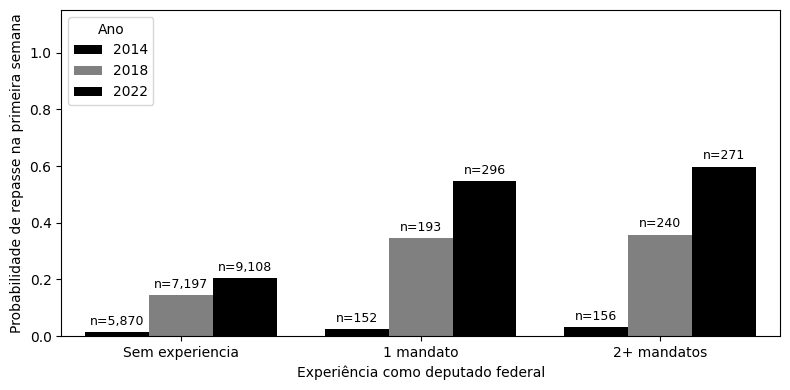

In [12]:
# Probabilidade de repasse na 1ª semana — por experiência como Dep. Federal

df_plot = (
    rrd_df_merge
    .groupby(["exp_deputado_federal", "ano_eleicao"], observed=True)
    .agg(prob_repasse=("repasse_semana1", "mean"), n_obs=("repasse_semana1", "count"))
    .reset_index()
)

fig_bar, ax = plt.subplots(figsize=(8, 4))
ax = sns.barplot(
    data=df_plot,
    x="exp_deputado_federal",
    y="prob_repasse",
    hue="ano_eleicao",
    palette=["black", "grey"],
    ax=ax,
)
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        for _, row in df_plot.iterrows():
            if abs(height - row["prob_repasse"]) < 0.001:
                labels.append(f"n={row['n_obs']:,.0f}")
                break
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_ylabel("Probabilidade de repasse na primeira semana")
ax.set_xlabel("Experiência como deputado federal")
ax.set_ylim(0, 1.15)
ax.legend(title="Ano", loc="upper left")
plt.tight_layout()
plt.show()

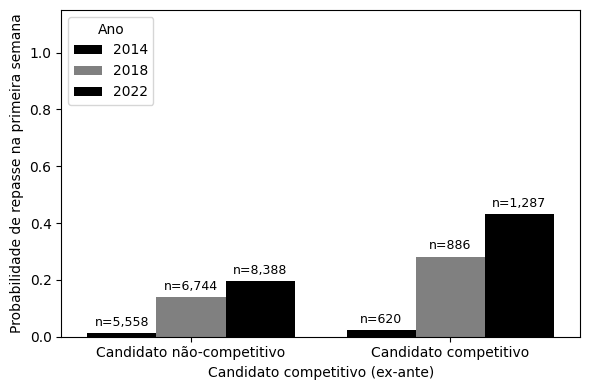

In [13]:
# Probabilidade de repasse na 1ª semana — competitivo vs. não-competitivo (ex-ante)

df_plot_cs = (
    rrd_df_merge.groupby(["candidato_competitivo", "ano_eleicao"], observed=True)
    .agg(prob_repasse=("repasse_semana1", "mean"), n_obs=("repasse_semana1", "count"))
    .reset_index()
)
df_plot_cs["grupo_cs"] = df_plot_cs["candidato_competitivo"].map(
    {True: "Candidato competitivo", False: "Candidato não-competitivo"}
)

fig_bar2, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(
    data=df_plot_cs,
    x="grupo_cs",
    y="prob_repasse",
    hue="ano_eleicao",
    palette=["black", "grey"],
    ax=ax,
)
for container in ax.containers:
    labels = []
    for bar in container:
        height = bar.get_height()
        for _, row in df_plot_cs.iterrows():
            if abs(height - row["prob_repasse"]) < 0.001:
                labels.append(f"n={row['n_obs']:,.0f}")
                break
        else:
            labels.append("")
    ax.bar_label(container, labels=labels, padding=3, fontsize=9)

ax.set_ylabel("Probabilidade de repasse na primeira semana")
ax.set_xlabel("Candidato competitivo (ex-ante)")
ax.set_ylim(0, 1.15)
ax.legend(title="Ano", loc="upper left")
plt.tight_layout()
plt.show()

## Robustez: Kaplan-Meier com Timing do Maior Repasse

Mesma estrutura da análise principal, mas usando como evento o dia do **maior repasse** diário de recursos partidários (FP/PJ_ROTEADO/FEFC) em vez do primeiro repasse.

In [14]:
from cap3_survival_features import (
    carregar_receitas,
    calcular_dias_maior_receita,
    preparar_survival_maior,
    FONTES_PARTIDO,
)

# Carrega dados transacionais (pesado — reutilizar se já em memória)
_df_rec_all     = carregar_receitas()
_df_rec_partido = _df_rec_all[_df_rec_all["fonte_tipo"].isin(FONTES_PARTIDO)].copy()

df_maior = calcular_dias_maior_receita(_df_rec_partido)

print("Candidatos com maior repasse computado por ano:")
print(df_maior.groupby("ano_eleicao").size().rename("n"))
print("\nValor mediano do maior repasse (R$):")
print(df_maior.groupby("ano_eleicao")["vr_maior_receita"].median().round(0))

Candidatos com maior repasse computado por ano:
ano_eleicao
2014    2356
2018    5830
2022    8596
Name: n, dtype: int64

Valor mediano do maior repasse (R$):
ano_eleicao
2014     5000.0
2018    10000.0
2022    50000.0
Name: vr_maior_receita, dtype: float64


In [15]:
survival_maior = {
    ano: preparar_survival_maior(rrd_df_merge, df_maior, ano)
    for ano in [2014, 2018, 2022]
}

for ano, df in survival_maior.items():
    ev   = int(df["event"].sum())
    cens = int((df["event"] == 0).sum())
    pct  = ev / len(df) * 100
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"{ano}{label} — N={len(df):,} | eventos={ev:,} ({pct:.0f}%) | censurados={cens:,}")

2014 (pré-FEFC / FP) — N=6,177 | eventos=2,298 (37%) | censurados=3,879
2018 — N=7,626 | eventos=5,281 (69%) | censurados=2,345
2022 — N=9,672 | eventos=8,370 (87%) | censurados=1,302


In [16]:
# Kaplan-Meier — timing do MAIOR repasse — competitivo vs. não-competitivo

cores_km  = {"Candidato competitivo": "black", "Candidato não-competitivo": "lightgrey"}
dashes_km = {"Candidato competitivo": "solid",  "Candidato não-competitivo": "dot"}
grupos_km = ["Candidato competitivo", "Candidato não-competitivo"]

_cands_2014_maior = (
    cs_lookup[cs_lookup["ano_eleicao"] == 2014]
    [["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"]]
    .drop_duplicates()
)


def _km_maior_2014(fonte_tipos=None):
    src = _df_rec_partido if fonte_tipos is None else _df_rec_partido[_df_rec_partido["fonte_tipo"].isin(fonte_tipos)]
    src14 = src[src["ano_eleicao"] == 2014].copy()
    daily = (
        src14.groupby(["sg_uf", "sg_partido", "nr_candidato", "dt_receita"])["vr_receita"]
        .sum().reset_index()
    )
    idx_max = daily.groupby(["sg_uf", "sg_partido", "nr_candidato"])["vr_receita"].idxmax()
    maior14 = daily.loc[idx_max, ["sg_uf", "sg_partido", "nr_candidato", "dt_receita"]].copy()
    maior14["dias_maior"] = (maior14["dt_receita"] - JANELAS[2014][0]).dt.days
    d = _cands_2014_maior.merge(
        maior14[["sg_uf", "sg_partido", "nr_candidato", "dias_maior"]],
        on=["sg_uf", "sg_partido", "nr_candidato"], how="left",
    )
    d["duration"]        = d["dias_maior"].fillna(DURACAO[2014]).clip(upper=DURACAO[2014])
    d["event"]           = d["dias_maior"].notna().astype(int)
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[2014] / 7)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    return d


def _km_maior_1822(df_surv, ano):
    d = df_surv.merge(
        cs_lookup.loc[
            cs_lookup["ano_eleicao"] == ano,
            ["sg_uf", "sg_partido", "nr_candidato", "candidato_competitivo"],
        ],
        on=["sg_uf", "sg_partido", "nr_candidato"], how="left",
    )
    d["candidato_competitivo"] = d["candidato_competitivo"].fillna(False)
    d["grupo_cs"]        = d["candidato_competitivo"].map(
        {True: "Candidato competitivo", False: "Candidato não-competitivo"}
    )
    d["duration_semana"] = (d["duration"] / 7).clip(upper=DURACAO[ano] / 7)
    return d


PAINEIS_KM_MAIOR = [
    ("2014 — Total",                _km_maior_2014(None)),
    ("2014 — Fundo Partidário",     _km_maior_2014(["FP"])),
    ("2014 — PJ → Partido → Cand.", _km_maior_2014(["PJ_ROTEADO"])),
    ("2018",                         _km_maior_1822(survival_maior[2018], 2018)),
    ("2022",                         _km_maior_1822(survival_maior[2022], 2022)),
]

specs_km = [
    [{"type": "xy"}, {"type": "xy"}, {"type": "xy"}],
    [{"type": "xy"}, {"type": "xy"}, None],
]
pos_km = {i: (1 + i // 3, (i % 3) + 1) for i in range(len(PAINEIS_KM_MAIOR))}

fig_km_maior = make_subplots(
    rows=2, cols=3,
    shared_yaxes=True,
    subplot_titles=[p[0] for p in PAINEIS_KM_MAIOR],
    specs=specs_km,
    vertical_spacing=0.18,
    horizontal_spacing=0.06,
)

for i, (titulo, d) in enumerate(PAINEIS_KM_MAIOR):
    row, col = pos_km[i]
    n_ev = int(d["event"].sum())
    print(f"{titulo}: N={len(d):,} | eventos={n_ev:,} ({n_ev/len(d)*100:.0f}%) | censurados={len(d)-n_ev:,}")
    for grupo in grupos_km:
        mask = d["grupo_cs"] == grupo
        kmf = KaplanMeierFitter()
        kmf.fit(d.loc[mask, "duration_semana"], event_observed=d.loc[mask, "event"], label=grupo)
        sf = kmf.survival_function_
        fig_km_maior.add_trace(
            go.Scatter(
                x=kmf.timeline, y=sf[grupo].values,
                mode="lines", name=grupo,
                showlegend=(i == 0),
                line=dict(color=cores_km[grupo], width=2.5, dash=dashes_km[grupo]),
            ),
            row=row, col=col,
        )

fig_km_maior.update_layout(
    legend=dict(
        title="Candidato competitivo (ex-ante)",
        orientation="h", x=0.5, xanchor="center", y=1.12, yanchor="top",
    ),
    height=640, width=1200, template="plotly_white",
    margin=dict(t=80, b=50),
)
fig_km_maior.update_xaxes(title_text="Semana da campanha", dtick=1)
fig_km_maior.update_yaxes(title_text="S(t)", range=[0, 1.05], col=1)

fig_km_maior.write_image("figs/cap3_survival_km_maior_cs.png", scale=2)
fig_km_maior.show(config={"staticPlot": True})

2014 — Total: N=6,178 | eventos=2,298 (37%) | censurados=3,880
2014 — Fundo Partidário: N=6,178 | eventos=491 (8%) | censurados=5,687
2014 — PJ → Partido → Cand.: N=6,178 | eventos=2,027 (33%) | censurados=4,151
2018: N=7,626 | eventos=5,281 (69%) | censurados=2,345
2022: N=9,672 | eventos=8,370 (87%) | censurados=1,302


In [17]:
# Cox PH com timing do maior repasse — 2014 | 2018 | 2022

cox_maior = {}
for ano, df in survival_maior.items():
    cph = CoxPHFitter()
    cph.fit(
        df[COVS_MODELO + ["duration", "event", "partido_uf"]],
        duration_col="duration",
        event_col="event",
        cluster_col="partido_uf",
    )
    cox_maior[ano] = cph
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"\n=== Cox PH [maior repasse] — {ano}{label} ===")
    cph.print_summary(decimals=3)

print("\nC-index (maior repasse):")
for ano, cph in cox_maior.items():
    label = " (pré-FEFC / FP)" if ano == 2014 else ""
    print(f"  {ano}{label}: C = {cph.concordance_index_:.4f}")


=== Cox PH [maior repasse] — 2014 (pré-FEFC / FP) ===


<lifelines.CoxPHFitter: fitted with 6177 total observations, 3879 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6177
number of events observed = 2298
   partial log-likelihood = -19400.023
         time fit was run = 2026-06-09 23:41:57 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.424     1.527     0.040           0.346           0.502               1.413               1.651
n_eleicoes_deputado_estadual  0.389     1.475     0.042           0.306           0.471               1.358               1.602
n_eleicoes_vereador           0.012     1.012     0.023          -0.034           0.058               0.967               1.059
n_eleicoes_prefeito          -0.050     0.951     0.037          -0.122           0.022               0.885               1.023
n_eleicoes_governador         0.496     1.643     0.251           0.005           0.988               1.005               2.685
n_eleicoes_senador            0.386     1.472     0.273          -0.149           0.922               0.862               2.513
prop_votos_nominais_lag       0.804     2.235     0.193           0.426           1.182               1.532               3.261
log_qt_vaga                   0.042     1.043     0.085          -0.124           0.209               0.883               1.232

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 10.637 <0.0005    85.370
n_eleicoes_deputado_estadual   0.000  9.198 <0.0005    64.571
n_eleicoes_vereador            0.000  0.506   0.613     0.707
n_eleicoes_prefeito            0.000 -1.356   0.175     2.513
n_eleicoes_governador          0.000  1.981   0.048     4.393
n_eleicoes_senador             0.000  1.416   0.157     2.673
prop_votos_nominais_lag        0.000  4.171 <0.0005    15.011
log_qt_vaga                    0.000  0.496   0.620     0.689
---
Concordance = 0.571
Partial AIC = 38816.046
log-likelihood ratio test = 330.460 on 8 df
-log2(p) of ll-ratio test = 218.830


=== Cox PH [maior repasse] — 2018 ===


<lifelines.CoxPHFitter: fitted with 7626 total observations, 2345 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 7626
number of events observed = 5281
   partial log-likelihood = -44336.791
         time fit was run = 2026-06-09 23:41:59 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.500     1.649     0.037           0.428           0.573               1.534               1.773
n_eleicoes_deputado_estadual  0.384     1.468     0.041           0.304           0.464               1.355               1.590
n_eleicoes_vereador           0.051     1.052     0.018           0.015           0.087               1.015               1.090
n_eleicoes_prefeito           0.047     1.049     0.042          -0.036           0.130               0.965               1.139
n_eleicoes_governador         0.742     2.099     0.217           0.316           1.167               1.372               3.213
n_eleicoes_senador            2.477    11.910     0.320           1.849           3.105               6.355              22.320
prop_votos_nominais_lag       0.483     1.621     0.191           0.109           0.857               1.115               2.356
log_qt_vaga                  -0.089     0.915     0.069          -0.224           0.046               0.799               1.047

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 13.530 <0.0005   136.143
n_eleicoes_deputado_estadual   0.000  9.417 <0.0005    67.547
n_eleicoes_vereador            0.000  2.767   0.006     7.466
n_eleicoes_prefeito            0.000  1.119   0.263     1.926
n_eleicoes_governador          0.000  3.416   0.001    10.618
n_eleicoes_senador             0.000  7.730 <0.0005    46.406
prop_votos_nominais_lag        0.000  2.530   0.011     6.453
log_qt_vaga                    0.000 -1.298   0.194     2.363
---
Concordance = 0.569
Partial AIC = 88689.583
log-likelihood ratio test = 713.495 on 8 df
-log2(p) of ll-ratio test = 491.815


=== Cox PH [maior repasse] — 2022 ===


<lifelines.CoxPHFitter: fitted with 9672 total observations, 1302 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 9672
number of events observed = 8370
   partial log-likelihood = -70857.419
         time fit was run = 2026-06-09 23:42:01 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.289     1.334     0.031           0.229           0.348               1.257               1.417
n_eleicoes_deputado_estadual  0.264     1.302     0.036           0.194           0.335               1.214               1.398
n_eleicoes_vereador           0.012     1.012     0.011          -0.009           0.034               0.991               1.034
n_eleicoes_prefeito           0.006     1.006     0.007          -0.009           0.020               0.991               1.020
n_eleicoes_governador         0.271     1.311     0.204          -0.130           0.671               0.878               1.955
n_eleicoes_senador            0.642     1.900     0.295           0.063           1.220               1.065               3.388
prop_votos_nominais_lag       0.275     1.317     0.159          -0.037           0.588               0.964               1.800
log_qt_vaga                  -0.054     0.947     0.047          -0.146           0.038               0.864               1.039

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000  9.447 <0.0005    67.958
n_eleicoes_deputado_estadual   0.000  7.334 <0.0005    42.027
n_eleicoes_vereador            0.000  1.102   0.271     1.886
n_eleicoes_prefeito            0.000  0.734   0.463     1.112
n_eleicoes_governador          0.000  1.325   0.185     2.433
n_eleicoes_senador             0.000  2.174   0.030     5.075
prop_votos_nominais_lag        0.000  1.729   0.084     3.576
log_qt_vaga                    0.000 -1.144   0.253     1.986
---
Concordance = 0.556
Partial AIC = 141730.838
log-likelihood ratio test = 391.875 on 8 df
-log2(p) of ll-ratio test = 262.398


C-index (maior repasse):
  2014 (pré-FEFC / FP): C = 0.5713
  2018: C = 0.5691
  2022: C = 0.5563


In [18]:
# Cox PH [maior repasse por canal] — 2014: Fundo Partidário | PJ → Partido → Cand.
# Objetivo: testar H2b (front-loading do investimento principal) em cada canal separadamente.
# FP: ~491 eventos (8%) — IC largo esperado | PJ_ROTEADO: ~2.027 eventos (33%)

cox_maior_2014_canais = {}
for canal in ["FP", "PJ_ROTEADO"]:
    df_canal = _df_rec_partido[
        (_df_rec_partido["ano_eleicao"] == 2014) & (_df_rec_partido["fonte_tipo"] == canal)
    ]
    df_maior_canal = calcular_dias_maior_receita(df_canal)
    df_s = preparar_survival_maior(rrd_df_merge, df_maior_canal, 2014)

    ev  = int(df_s["event"].sum())
    pct = ev / len(df_s) * 100
    print(f"2014 — {canal}: N={len(df_s):,} | eventos={ev:,} ({pct:.0f}%) | censurados={len(df_s)-ev:,}")

    cph = CoxPHFitter()
    cph.fit(
        df_s[COVS_MODELO + ["duration", "event", "partido_uf"]],
        duration_col="duration",
        event_col="event",
        cluster_col="partido_uf",
    )
    cox_maior_2014_canais[canal] = cph
    print(f"=== Cox PH [maior repasse] — 2014 — {canal} ===")
    cph.print_summary(decimals=3)

print("C-index (maior repasse por canal):")
for canal, cph in cox_maior_2014_canais.items():
    print(f"  2014 — {canal}: C = {cph.concordance_index_:.4f}")


2014 — FP: N=6,177 | eventos=491 (8%) | censurados=5,686
=== Cox PH [maior repasse] — 2014 — FP ===


<lifelines.CoxPHFitter: fitted with 6177 total observations, 5686 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6177
number of events observed = 491
   partial log-likelihood = -4243.821
         time fit was run = 2026-06-09 23:42:05 UTC

---
                                coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                       
n_eleicoes_deputado_federal    0.070     1.073     0.092          -0.110           0.250               0.896               1.284
n_eleicoes_deputado_estadual  -0.062     0.940     0.146          -0.349           0.225               0.705               1.252
n_eleicoes_vereador           -0.001     0.999     0.041          -0.081           0.079               0.922               1.082
n_eleicoes_prefeito           -0.262     0.770     0.372          -0.991           0.467               0.371               1.596
n_eleicoes_governador          0.933     2.541     0.741          -0.520           2.385               0.595              10.859
n_eleicoes_senador           -12.282     0.000     0.512         -13.285         -11.279               0.000               0.000
prop_votos_nominais_lag        1.730     5.639     0.322           1.099           2.361               3.000              10.599
log_qt_vaga                   -0.001     0.999     0.151          -0.297           0.294               0.743               1.342

                              cmp to       z       p  -log2(p)
covariate                                                     
n_eleicoes_deputado_federal    0.000   0.765   0.444     1.170
n_eleicoes_deputado_estadual   0.000  -0.424   0.672     0.574
n_eleicoes_vereador            0.000  -0.024   0.981     0.028
n_eleicoes_prefeito            0.000  -0.704   0.482     1.054
n_eleicoes_governador          0.000   1.259   0.208     2.265
n_eleicoes_senador             0.000 -24.005 <0.0005   420.589
prop_votos_nominais_lag        0.000   5.373 <0.0005    23.622
log_qt_vaga                    0.000  -0.008   0.994     0.009
---
Concordance = 0.522
Partial AIC = 8503.642
log-likelihood ratio test = 43.809 on 8 df
-log2(p) of ll-ratio test = 20.625

2014 — PJ_ROTEADO: N=6,177 | eventos=2,027 (33%) | censurados=4,150
=== Cox PH [maior repasse] — 2014 — PJ_ROTEADO ===


<lifelines.CoxPHFitter: fitted with 6177 total observations, 4150 right-censored observations>
             duration col = 'duration'
                event col = 'event'
              cluster col = 'partido_uf'
          robust variance = True
      baseline estimation = breslow
   number of observations = 6177
number of events observed = 2027
   partial log-likelihood = -17143.267
         time fit was run = 2026-06-09 23:42:07 UTC

---
                               coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                      
n_eleicoes_deputado_federal   0.488     1.629     0.041           0.408           0.568               1.504               1.764
n_eleicoes_deputado_estadual  0.417     1.517     0.043           0.332           0.502               1.393               1.652
n_eleicoes_vereador           0.010     1.010     0.026          -0.040           0.060               0.960               1.062
n_eleicoes_prefeito          -0.033     0.967     0.032          -0.096           0.029               0.908               1.030
n_eleicoes_governador         0.604     1.829     0.219           0.174           1.033               1.190               2.809
n_eleicoes_senador            0.524     1.688     0.271          -0.008           1.056               0.992               2.874
prop_votos_nominais_lag       0.566     1.761     0.202           0.169           0.962               1.184               2.618
log_qt_vaga                   0.035     1.035     0.087          -0.135           0.205               0.874               1.227

                              cmp to      z       p  -log2(p)
covariate                                                    
n_eleicoes_deputado_federal    0.000 11.971 <0.0005   107.296
n_eleicoes_deputado_estadual   0.000  9.594 <0.0005    70.006
n_eleicoes_vereador            0.000  0.384   0.701     0.512
n_eleicoes_prefeito            0.000 -1.046   0.296     1.759
n_eleicoes_governador          0.000  2.755   0.006     7.413
n_eleicoes_senador             0.000  1.929   0.054     4.217
prop_votos_nominais_lag        0.000  2.795   0.005     7.592
log_qt_vaga                    0.000  0.401   0.688     0.539
---
Concordance = 0.575
Partial AIC = 34302.534
log-likelihood ratio test = 346.671 on 8 df
-log2(p) of ll-ratio test = 230.318

C-index (maior repasse por canal):
  2014 — FP: C = 0.5218
  2014 — PJ_ROTEADO: C = 0.5749


In [19]:
# Tabela comparativa: HR(primeiro repasse) x HR(maior repasse) — 2014 canais | 2018 | 2022

def extrair_hr(cph, label):
    s = cph.summary[["exp(coef)", "p"]].copy()
    s.columns = [f"HR_{label}", f"p_{label}"]
    return s

covs_display = {
    "n_eleicoes_deputado_federal":  "Mandatos Dep. Federal",
    "n_eleicoes_deputado_estadual": "Mandatos Dep. Estadual",
    "n_eleicoes_prefeito":          "Mandatos Prefeito",
    "n_eleicoes_governador":        "Mandatos Governador",
    "n_eleicoes_senador":           "Mandatos Senador",
    "prop_votos_nominais_lag":      "Prop. votos nominais t-1",
    "log_qt_vaga":                  "log(Magnitude)",
}

configs = [
    ("1rep_2014",      cox_results[2014]),
    ("maior_2014_tot", cox_maior[2014]),
    ("maior_2014_fp",  cox_maior_2014_canais["FP"]),
    ("maior_2014_pj",  cox_maior_2014_canais["PJ_ROTEADO"]),
    ("1rep_2018",      cox_results[2018]),
    ("maior_2018",     cox_maior[2018]),
    ("1rep_2022",      cox_results[2022]),
    ("maior_2022",     cox_maior[2022]),
]

tabs = [extrair_hr(cph, lbl) for lbl, cph in configs]
tab_comp = pd.concat(tabs, axis=1).loc[list(covs_display.keys())]
tab_comp.index = tab_comp.index.map(covs_display)

with pd.option_context("display.float_format", "{:.3f}".format, "display.max_columns", 20, "display.width", 200):
    print("Hazard Ratios — primeiro vs. maior repasse")
    print(tab_comp.to_string())

# LaTeX para o capítulo
col_ordem = ["1rep_2014", "maior_2014_tot", "maior_2014_fp", "maior_2014_pj",
             "1rep_2018", "maior_2018", "1rep_2022", "maior_2022"]

def fmt_hr(hr, p):
    stars = "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.1 else ""
    return f"{hr:.2f}{stars}"

print("% LaTeX (Tabela 4.2)")
print("\begin{tabular}{l" + "r" * len(col_ordem) + "}")
print("\hline")
header = ["1º rep.~2014", "maior 2014 Total", "maior 2014 FP", "maior 2014 PJ",
          "1º rep.~2018", "maior 2018", "1º rep.~2022", "maior 2022"]
print("  Covariável & " + " & ".join(header) + " \\\\")
print("\hline")
for cov, nome in covs_display.items():
    row_vals = [fmt_hr(tab_comp.loc[nome, f"HR_{lbl}"], tab_comp.loc[nome, f"p_{lbl}"]) for lbl in col_ordem]
    print(f"  {nome} & " + " & ".join(row_vals) + " \\\\")
print("\hline")
print("\end{tabular}")


Hazard Ratios — primeiro vs. maior repasse
                          HR_1rep_2014  p_1rep_2014  HR_maior_2014_tot  p_maior_2014_tot  HR_maior_2014_fp  p_maior_2014_fp  HR_maior_2014_pj  p_maior_2014_pj  HR_1rep_2018  p_1rep_2018  HR_maior_2018  p_maior_2018  HR_1rep_2022  p_1rep_2022  HR_maior_2022  p_maior_2022
covariate                                                                                                                                                                                                                                                                     
Mandatos Dep. Federal            1.631        0.000              1.527             0.000             1.073            0.444             1.629            0.000         1.544        0.000          1.649         0.000         1.365        0.000          1.334         0.000
Mandatos Dep. Estadual           1.491        0.000              1.475             0.000             0.940            0.672             1.517   